In [101]:
from skimage import data
import numpy as np
import matplotlib.pyplot as plt

# Image from data
img_astronaut = data.astronaut()
print("Image: Astronaut")
print(img_astronaut)

Image: Astronaut
[[[154 147 151]
  [109 103 124]
  [ 63  58 102]
  ...
  [127 120 115]
  [120 117 106]
  [125 119 110]]

 [[177 171 171]
  [144 141 143]
  [113 114 124]
  ...
  [127 118 112]
  [124 115 108]
  [121 116 105]]

 [[201 194 193]
  [182 178 175]
  [168 165 164]
  ...
  [128 120 117]
  [126 116 112]
  [124 114 109]]

 ...

 [[186 170 176]
  [186 170 177]
  [183 168 170]
  ...
  [  0   0   0]
  [  0   0   1]
  [  0   0   0]]

 [[183 169 170]
  [182 167 171]
  [185 164 176]
  ...
  [  0   0   1]
  [  1   1   1]
  [  0   0   0]]

 [[184 167 172]
  [183 165 169]
  [180 162 171]
  ...
  [  0   0   0]
  [  1   1   1]
  [  0   0   0]]]


In [102]:
# 8x8 Noise image
height = 8
width = 8
img_noise = np.random.rand(height,width,3)
img_noise = ((img_noise * 16)).astype(np.uint8) / 15
#Nums go 0-15, then normalize to get a float
#16 colors for each channel, 16x16x16 colors
#Now we have floats but to keep it like astronaut we go to int 0-255
img_noise = ((img_noise * 255)).astype(np.uint8)
print("Image: Noise")
print(img_noise)

Image: Noise
[[[136 187 238]
  [170  51 119]
  [238 187 238]
  [187 204  17]
  [  0 153 153]
  [170 187 170]
  [ 68 255 255]
  [102  68 221]]

 [[255 221 238]
  [187  34 170]
  [221  68  34]
  [ 68 255  34]
  [238 204 221]
  [119  17  85]
  [  0 221   0]
  [102 170 119]]

 [[238  17 187]
  [187  17  51]
  [187  85  51]
  [238  51  51]
  [ 17 255  68]
  [ 34 204 238]
  [187  51  51]
  [ 34  85   0]]

 [[ 34 170   0]
  [102 204 187]
  [ 34 238 204]
  [ 17 221 255]
  [153 136 170]
  [170  34  34]
  [ 68 204 102]
  [255 221  51]]

 [[221 170  51]
  [204   0   0]
  [ 68 187 255]
  [238 187  68]
  [102 255 170]
  [ 68 187 102]
  [  0 238 136]
  [204 204  85]]

 [[119 119 170]
  [ 51  17  34]
  [ 68 221 153]
  [ 34 119 187]
  [  0 136  51]
  [255 255  51]
  [ 17  34  68]
  [255 238 153]]

 [[ 85 102 119]
  [221  17 119]
  [ 34   0 221]
  [ 34  51 153]
  [  0  34  51]
  [ 17 238 187]
  [153 136 102]
  [204 136 102]]

 [[102  68 136]
  [255 119 187]
  [ 68  51  85]
  [221 221  51]
  [238  34 18

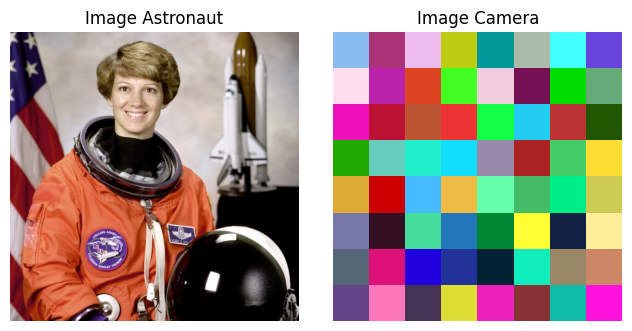

In [103]:
fig, ax = plt.subplots(1,2)
ax[0].axis("off")
ax[0].set_title("Image Astronaut")
ax[0].imshow(img_astronaut)

ax[1].axis("off")
ax[1].set_title("Image Camera")
ax[1].imshow(img_noise)

plt.tight_layout(pad=1, w_pad=2.5, h_pad=1.0)
plt.show()

# Image caracteristics

Img_Astronaut:

Dimension img_astronaut: 3
Resolution img_astronaut: 512 x 512 x 3
Total img_astronaut size: 786432
Min value img_astronaut: 0
Max value img_astronaut: 255
Max value red_channel: 255
Mean value img_astronaut: 114.60
Mean value blue_channel: 96.48
Amount of particular pixel value img_astronaut: 2526
Amount of particular pixel value img_astronaut green channel: 598


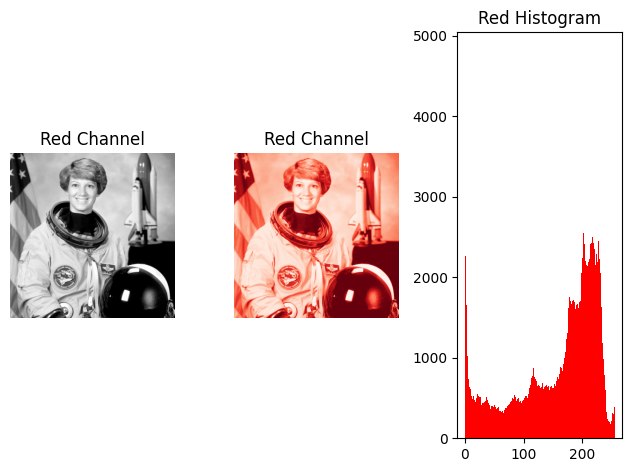

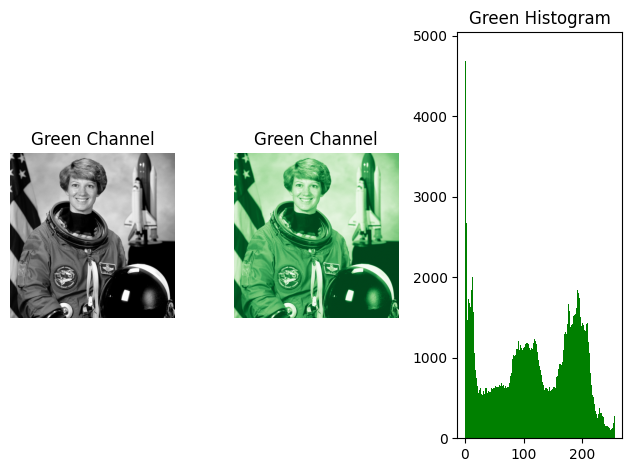

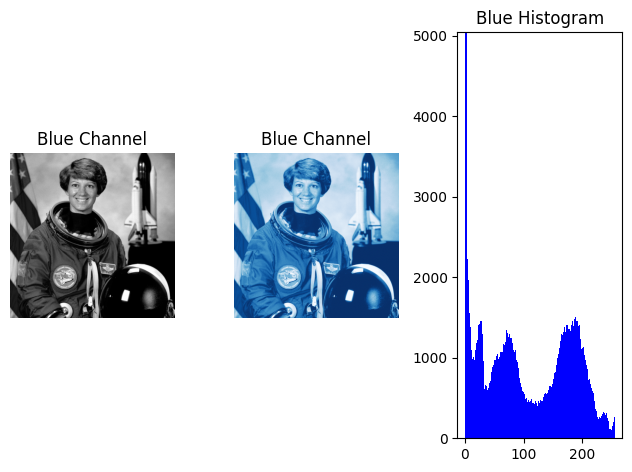

In [104]:
print("Img_Astronaut:\n")
print(f"Dimension img_astronaut: {img_astronaut.ndim}")
print(f"Resolution img_astronaut: {img_astronaut.shape[0]} x {img_astronaut.shape[1]} x {img_astronaut.shape[2]}")
print(f"Total img_astronaut size: {img_astronaut.size}")


red_channel = img_astronaut[:, :, 0]
green_channel = img_astronaut[:, :, 1]
blue_channel = img_astronaut[:, :, 2]

print(f"Min value img_astronaut: {np.min(img_astronaut)}")
print(f"Max value img_astronaut: {np.max(img_astronaut)}")
print(f"Max value red_channel: {np.max(red_channel)}")
print(f"Mean value img_astronaut: {np.mean(img_astronaut):.2f}")
print(f"Mean value blue_channel: {np.mean(blue_channel):.2f}")
print(f"Amount of particular pixel value img_astronaut: {np.sum(img_astronaut == 25)}")
print(f"Amount of particular pixel value img_astronaut green channel: {np.sum(green_channel == 25)}")

# Histograms

max_red = np.max(np.bincount(red_channel.ravel(), minlength=256)[2:])
max_green = np.max(np.bincount(green_channel.ravel(), minlength=256)[2:])
max_blue = np.max(np.bincount(blue_channel.ravel(), minlength=256)[2:])
y_limit = max(max_red, max_green, max_blue)
#Blue channel has a huge amount of 0 pixels, so i take a limit smaller to better analize the rest of the graphic

# Red
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Red Channel")
ax[0].imshow(red_channel, cmap='gray') 

ax[1].axis("off")
ax[1].set_title("Red Channel")
ax[1].imshow(red_channel, cmap='Reds_r') 

ax[2].set_title("Red Histogram")
ax[2].hist(np.ravel(red_channel), bins=256, color='red')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()

# Green
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Green Channel")
ax[0].imshow(green_channel, cmap='gray') 

ax[1].axis("off")
ax[1].set_title("Green Channel")
ax[1].imshow(green_channel, cmap='Greens_r') 

ax[2].set_title("Green Histogram")
ax[2].hist(np.ravel(green_channel), bins=256, color='green')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()

# Blue
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Blue Channel")
ax[0].imshow(blue_channel, cmap='gray') 
ax[1].axis("off")
ax[1].set_title("Blue Channel")
ax[1].imshow(blue_channel, cmap='Blues_r') 

ax[2].set_title("Blue Histogram")
ax[2].hist(np.ravel(blue_channel), bins=256, color='blue')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()


Img_noise:

Dimension img_noise: 3
Resolution img_noise: 8 x 8 x 3
Total img_noise size: 192
Min value img_noise: 0
Max value img_noise: 255
Max value red_channel: 255
Mean value img_noise: 128.92
Mean value blue_channel: 123.25
Amount of particular pixel value img_noise: 11
Amount of particular pixel value img_noise green channel: 2


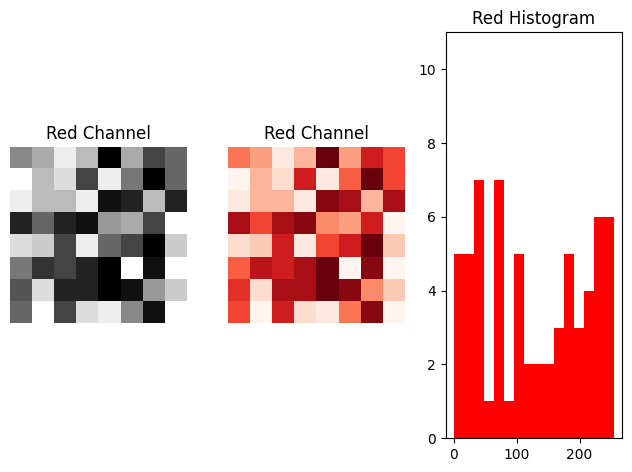

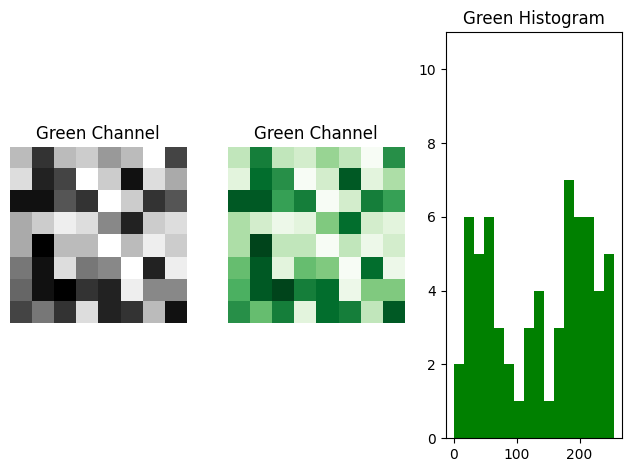

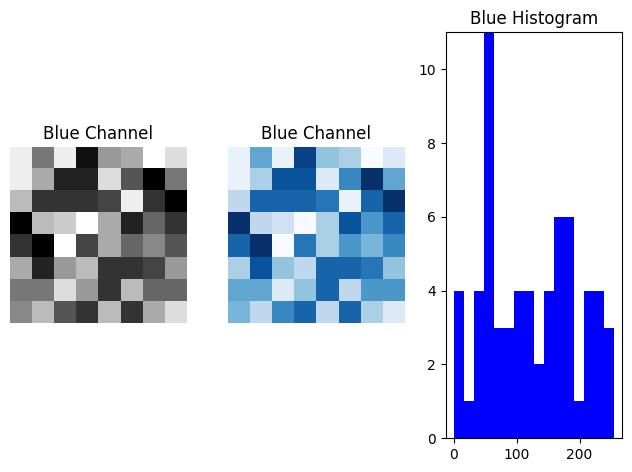

In [105]:
print("Img_noise:\n")
print(f"Dimension img_noise: {img_noise.ndim}")
print(f"Resolution img_noise: {img_noise.shape[0]} x {img_noise.shape[1]} x {img_noise.shape[2]}")
print(f"Total img_noise size: {img_noise.size}")


red_channel = img_noise[:, :, 0]
green_channel = img_noise[:, :, 1]
blue_channel = img_noise[:, :, 2]

print(f"Min value img_noise: {np.min(img_noise)}")
print(f"Max value img_noise: {np.max(img_noise)}")
print(f"Max value red_channel: {np.max(red_channel)}")
print(f"Mean value img_noise: {np.mean(img_noise):.2f}")
print(f"Mean value blue_channel: {np.mean(blue_channel):.2f}")
print(f"Amount of particular pixel value img_noise: {np.sum(img_noise == 0)}")
print(f"Amount of particular pixel value img_noise green channel: {np.sum(green_channel == 0)}")
#Its important to remember, that even though its 16 colors per channel, they are all across 0-255.
#print(red_channel)

# Histograms
max_red = np.max(np.bincount(red_channel.ravel(), minlength=16))
max_green = np.max(np.bincount(green_channel.ravel(), minlength=16))
max_blue = np.max(np.bincount(blue_channel.ravel(), minlength=16))
y_limit = max(max_red, max_green, max_blue)

# Red
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Red Channel")
ax[0].imshow(red_channel, cmap='gray') 

ax[1].axis("off")
ax[1].set_title("Red Channel")
ax[1].imshow(red_channel, cmap='Reds_r') 

ax[2].set_title("Red Histogram")
ax[2].hist(np.ravel(red_channel), bins=16, color='red')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()

# Green
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Green Channel")
ax[0].imshow(green_channel, cmap='gray') 

ax[1].axis("off")
ax[1].set_title("Green Channel")
ax[1].imshow(green_channel, cmap='Greens_r') 

ax[2].set_title("Green Histogram")
ax[2].hist(np.ravel(green_channel), bins=16, color='green')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()

# Blue
fig, ax = plt.subplots(1,3)
ax[0].axis("off")
ax[0].set_title("Blue Channel")
ax[0].imshow(blue_channel, cmap='gray') 
ax[1].axis("off")
ax[1].set_title("Blue Channel")
ax[1].imshow(blue_channel, cmap='Blues_r') 

ax[2].set_title("Blue Histogram")
ax[2].hist(np.ravel(blue_channel), bins=16, color='blue')
ax[2].set_ylim(0, y_limit)
plt.tight_layout(pad=1.0, w_pad=1, h_pad=1.5)
plt.show()


## Indexation

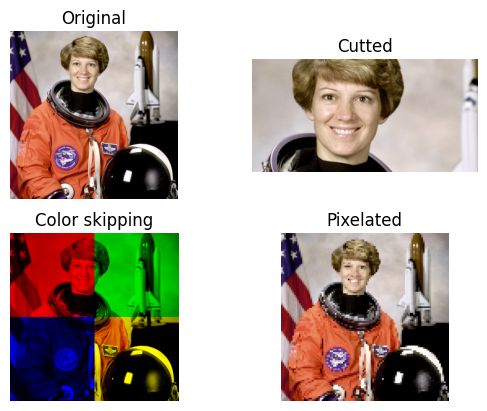

In [106]:
# start: 0 | end: size | step: 1
# This is a reference to the original image

### Original
fig, ax = plt.subplots(2,2)
ax[0][0].axis("off")
ax[0][0].set_title("Original")
ax[0][0].imshow(img_astronaut)

### Cut
cut = img_astronaut[50:200, 100:400]
ax[0][1].axis("off")
ax[0][1].set_title("Cutted")
ax[0][1].imshow(cut)

### Color mix
color_mix = img_astronaut.copy()
h, w, _ = color_mix.shape
mid_h, mid_w = h // 2, w // 2

#Top Left red, turn off channel 1,2
color_mix[:mid_h, :mid_w, 1:] = 0

# Top Right green, turn off channel 0,2
color_mix[:mid_h, mid_w:, 0] = 0
color_mix[:mid_h, mid_w:, 2] = 0

# Bottom Left blue, turn off 0,1
color_mix[mid_h:, :mid_w, :2] = 0

# Bottom Right Red+Green -> Turn off blue
color_mix[mid_h:, mid_w:, 2] = 0

ax[1][0].axis("off")
ax[1][0].set_title("Color skipping")
ax[1][0].imshow(color_mix)

### Pixelated
pixelated = img_astronaut[::5, ::5]
ax[1][1].axis("off")
ax[1][1].set_title("Pixelated")
ax[1][1].imshow(pixelated)

plt.show()

# Whole image Histogram

# RGB to B&W